In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("afl_stats.csv")
df.head()

,Game,Season,Date,Round,Home_Team,Home_Points,Away_Team,Away_Points,Winner,Home_Points_By,...,Home_Points_For_4,Away_Points_For_4,Home_Points_Against_4,Away_Points_Against_4,Home_Points_For_5,Away_Points_For_5,Home_Points_Against_5,Away_Points_Against_5,Home_Rank,Away_Rank
0,11728,2000,2000-03-08,R1,Richmond,94,Melbourne,92,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,11729,2000,2000-03-09,R1,Essendon,156,Port Adelaide,62,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,11730,2000,2000-03-10,R1,North Melbourne,111,West Coast,154,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,11731,2000,2000-03-11,R1,Adelaide,108,Footscray,131,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,11732,2000,2000-03-11,R1,Fremantle,107,Geelong,129,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


In [80]:
team_games = {}

for team in df.Home_Team.unique():
    home_games = df.Home_Team.value_counts()[team]

    away_games = df.Away_Team.value_counts()[team]
    
    games = int(home_games + away_games)

    team_games[team] = games

print(team_games)

{'Richmond': 520, 'Essendon': 519, 'North Melbourne': 518, 'Adelaide': 525, 'Fremantle': 518, 'St Kilda': 520, 'Carlton': 512, 'Hawthorn': 532, 'Melbourne': 518, 'Geelong': 546, 'Port Adelaide': 527, 'Collingwood': 538, 'Footscray': 525, 'West Coast': 530, 'Sydney': 542, 'Brisbane Lions': 527, 'Gold Coast': 259, 'GWS': 250}


In [81]:
team_wins = {}

for team in df.Home_Team.unique():
    home_wins = ((df['Home_Team'] == team) &
                 (df['Winner'] == 'Home')).sum()
    away_wins = ((df['Away_Team'] == team) &
                 (df['Winner'] == 'Away')).sum()

    wins = int(home_wins + away_wins)
    team_wins[team] = wins

print(team_wins)

{'Richmond': 252, 'Essendon': 246, 'North Melbourne': 236, 'Adelaide': 277, 'Fremantle': 245, 'St Kilda': 239, 'Carlton': 192, 'Hawthorn': 296, 'Melbourne': 217, 'Geelong': 361, 'Port Adelaide': 283, 'Collingwood': 299, 'Footscray': 253, 'West Coast': 278, 'Sydney': 318, 'Brisbane Lions': 256, 'Gold Coast': 69, 'GWS': 108}


In [97]:
team_win_percentage = {}

for team in team_games:
    win_percentage = team_wins[team]/team_games[team] * 100
    win_percentage = float(round(win_percentage, 1))
    print(team, ': ', win_percentage, '%')
    team_win_percentage[team] = win_percentage

print(team_win_percentage)

Richmond :  48.5 %
Essendon :  47.4 %
North Melbourne :  45.6 %
Adelaide :  52.8 %
Fremantle :  47.3 %
St Kilda :  46.0 %
Carlton :  37.5 %
Hawthorn :  55.6 %
Melbourne :  41.9 %
Geelong :  66.1 %
Port Adelaide :  53.7 %
Collingwood :  55.6 %
Footscray :  48.2 %
West Coast :  52.5 %
Sydney :  58.7 %
Brisbane Lions :  48.6 %
Gold Coast :  26.6 %
GWS :  43.2 %
{'Richmond': 48.5, 'Essendon': 47.4, 'North Melbourne': 45.6, 'Adelaide': 52.8, 'Fremantle': 47.3, 'St Kilda': 46.0, 'Carlton': 37.5, 'Hawthorn': 55.6, 'Melbourne': 41.9, 'Geelong': 66.1, 'Port Adelaide': 53.7, 'Collingwood': 55.6, 'Footscray': 48.2, 'West Coast': 52.5, 'Sydney': 58.7, 'Brisbane Lions': 48.6, 'Gold Coast': 26.6, 'GWS': 43.2}


In [98]:
sorted_percentage = dict(sorted(team_win_percentage.items(), key=lambda item: item[1]))
print(sorted_percentage)

{'Gold Coast': 26.6, 'Carlton': 37.5, 'Melbourne': 41.9, 'GWS': 43.2, 'North Melbourne': 45.6, 'St Kilda': 46.0, 'Fremantle': 47.3, 'Essendon': 47.4, 'Footscray': 48.2, 'Richmond': 48.5, 'Brisbane Lions': 48.6, 'West Coast': 52.5, 'Adelaide': 52.8, 'Port Adelaide': 53.7, 'Hawthorn': 55.6, 'Collingwood': 55.6, 'Sydney': 58.7, 'Geelong': 66.1}


Text(0, 0.5, 'Team')

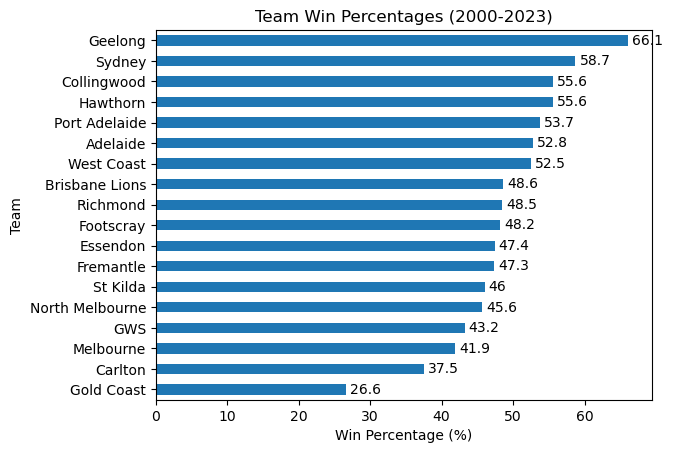

In [99]:
df = pd.Series(sorted_percentage)

ax = df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Team Win Percentages (2000-2023)')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')